# Phase 2 — N-gram language model

**N-Ticipate**, an n-gram + HMM autocomplete engine.

Phase 1 produced a cleaned, split, `<UNK>`-ed corpus. This notebook counts
unigrams, bigrams and trigrams over it and scores words under four smoothing
methods, then measures which one the app should actually ship.

| Method | Why it is here |
| --- | --- |
| `mle` | Baseline. Demonstrates the zero-probability problem. |
| `laplace` | Add-k. The classic textbook fix. |
| `stupid_backoff` | Fast, unnormalised. What the running app uses. |
| `kneser_ney` | Interpolated KN. The quality ceiling to compare against. |

One thing to keep in view throughout: `stupid_backoff` is **not a probability
distribution**. Its scores rank correctly but do not sum to one over the
vocabulary, so its "perplexity" is not strictly comparable with the other
three. The model exposes that as `is_normalized` rather than quietly printing
a number, and the tables below flag it.

In [1]:
import sys, pathlib, math, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
from nticipate.ngram import *
from nticipate.preprocess import Corpus, default_processed_path, apply_truecase, truecase_word
from nticipate.config import data_dir

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110

corpus = Corpus.load(default_processed_path('brown.json'))
print(f'train {len(corpus.train):,}  dev {len(corpus.dev):,}  test {len(corpus.test):,} sentences')

train 45,610  dev 5,701  test 5,702 sentences


## 1. Counting

Each sentence is padded once with `order-1` BOS markers and one EOS, and every
order is extracted from that same padded sequence. Padding per-order instead
would give the lower orders a different number of boundary tokens, and the
backoff levels would then disagree about how often a sentence starts.

In [2]:
t = time.time()
model = NgramModel(order=3, smoothing='stupid_backoff').fit(corpus.train)
print(f'fitted in {time.time() - t:.1f}s')
print(model)

stats = model.stats()
for k, n in stats.ngram_counts.items():
    print(f'  {k}-grams: {n:>10,}')

fitted in 8.5s
NgramModel(order=3, smoothing='stupid_backoff', vocab=24637, ngrams=1050690)
  1-grams:     24,636
  2-grams:    335,687
  3-grams:    690,367


In [3]:
# Counts are plain dictionaries, so the model can be read by hand.
print('count(the cat sat)   :', model.counts[3][('the', 'cat')]['sat'])
print('count(the cat *)     :', model.totals[3][('the', 'cat')])
print('P(sat | the cat)     :', model.counts[3][('the', 'cat')]['sat'] / model.totals[3][('the', 'cat')])
print()
print('top continuations of "in the":')
for w, c in model.counts[3][('in', 'the')].most_common(8):
    print(f'  {w:>12}  {c:>4}')

count(the cat sat)   : 0
count(the cat *)     : 6
P(sat | the cat)     : 0.0

top continuations of "in the":
         <UNK>   175
         world    73
         first    72
        united    59
          same    57
          past    49
          last    39
         field    35


## 2. The zero-probability problem

MLE is a perfectly good estimator for anything it has seen, and useless for
anything it has not. One unseen trigram in a held-out sentence sends the whole
perplexity to infinity, no matter how well the model does on the rest.

In [4]:
mle = NgramModel(order=3, smoothing='mle').fit(corpus.train)

print('P(sat | the cat) =', mle.prob('sat', ['the', 'cat']))
print('P(sat | zzz qqq) =', mle.prob('sat', ['zzz', 'qqq']))
print('log P            =', mle.logprob('sat', ['zzz', 'qqq']))
print()
print('perplexity on dev:', mle.perplexity(corpus.dev))

P(sat | the cat) = 0.0
P(sat | zzz qqq) = 0.0
log P            = -inf

perplexity on dev: inf


Every other method exists to make that number finite. The three ways of doing
it are: add mass to everything (Laplace), fall back to a shorter context
(stupid backoff), or interpolate the orders together (Kneser-Ney).

In [5]:
for method in SMOOTHING_METHODS:
    m = NgramModel(order=3, smoothing=method)
    m.counts, m.totals, m.continuations, m.cont_totals = (
        mle.counts, mle.totals, mle.continuations, mle.cont_totals)
    m.vocab = mle.vocab
    print(f'{method:>16}  P(sat | zzz qqq) = {m.prob("sat", ["zzz", "qqq"]):.3e}')

             mle  P(sat | zzz qqq) = 0.000e+00
         laplace  P(sat | zzz qqq) = 4.059e-05
  stupid_backoff  P(sat | zzz qqq) = 1.990e-05
      kneser_ney  P(sat | zzz qqq) = 1.758e-04


## 3. Do the scores sum to one?

Worth checking rather than assuming. A method that does not sum to one is not
wrong to use — but its perplexity is not a perplexity.

In [6]:
for method in SMOOTHING_METHODS:
    m = NgramModel(order=2, smoothing=method).fit(corpus.train[:2000])
    mass = m.distribution_mass(['the'])
    flag = 'normalised' if m.is_normalized else 'NOT a distribution'
    print(f'{method:>16}  sum over vocab after "the" = {mass:.4f}   ({flag})')

             mle  sum over vocab after "the" = 1.0000   (normalised)


         laplace  sum over vocab after "the" = 1.0000   (normalised)


  stupid_backoff  sum over vocab after "the" = 1.3061   (NOT a distribution)


      kneser_ney  sum over vocab after "the" = 1.0000   (normalised)


## 4. Perplexity sweep

The headline table: perplexity on the held-out dev split for every
(order, smoothing) pair. Counting is done once per order and the smoothing
swapped on the fitted model — refitting per method would quadruple the runtime
for identical counts.

In [7]:
t = time.time()
rows = perplexity_sweep(corpus.train, corpus.dev, orders=(1, 2, 3))
print(f'swept in {time.time() - t:.0f}s\n')

print(f'{"n":>2}  {"smoothing":>16}  {"perplexity":>12}  {"normalised":>10}  {"n-grams":>11}')
print('-' * 62)
for r in rows:
    p = 'inf' if math.isinf(r['perplexity']) else f'{r["perplexity"]:,.1f}'
    print(f'{r["order"]:>2}  {r["smoothing"]:>16}  {p:>12}  {str(r["normalized"]):>10}  {r["ngrams"]:>11,}')

swept in 28s

 n         smoothing    perplexity  normalised      n-grams
--------------------------------------------------------------
 1               mle         700.4        True       24,636
 1           laplace         703.5        True       24,636
 1    stupid_backoff         700.4       False       24,636
 1        kneser_ney         700.4        True       24,636
 2               mle           inf        True      360,323
 2           laplace       1,701.7        True      360,323
 2    stupid_backoff         222.2       False      360,323
 2        kneser_ney         238.4        True      360,323
 3               mle           inf        True    1,050,690
 3           laplace       9,704.3        True    1,050,690
 3    stupid_backoff         291.3       False    1,050,690
 3        kneser_ney         221.1        True    1,050,690


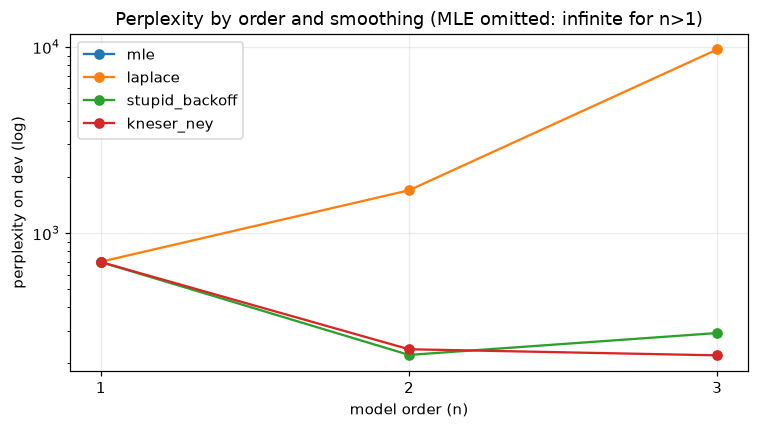

In [8]:
fig, ax = plt.subplots()
for method in SMOOTHING_METHODS:
    xs = [r['order'] for r in rows if r['smoothing'] == method and math.isfinite(r['perplexity'])]
    ys = [r['perplexity'] for r in rows if r['smoothing'] == method and math.isfinite(r['perplexity'])]
    if xs:
        ax.plot(xs, ys, marker='o', label=method)
ax.set_yscale('log')
ax.set_xticks([1, 2, 3])
ax.set_xlabel('model order (n)')
ax.set_ylabel('perplexity on dev (log)')
ax.set_title('Perplexity by order and smoothing (MLE omitted: infinite for n>1)')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Three things in that table are worth the report's attention.

**MLE is infinite for n > 1** and finite at n = 1. The unigram model is finite
only because Phase 1 closed the vocabulary — every dev token is either known or
already `<UNK>`. The moment context is involved, unseen n-grams appear and the
estimator collapses.

**Laplace gets *worse* as the order rises** — roughly 704 -> 1,702 -> 9,704.
That is not a bug. Add-1 hands one pseudo-count to each of ~24,600 vocabulary
items for *every* context, and trigram contexts are mostly seen once or twice,
so the smoothing mass swamps the evidence. The textbook method is the worst
performer at the order we actually want to ship.

**Kneser-Ney is the only method that improves at n = 3** (238 -> 221). It is
the quality ceiling, as expected.

## 5. Why Kneser-Ney works: continuation counts

KN scores a word by how many *distinct contexts* it appears in, not how often
it appears. The standard illustration: `Francisco` is a frequent word that
follows only `San`, so it should never be predicted after an arbitrary
context. Raw frequency cannot express that; a continuation count can.

In [9]:
uni = model.counts[1][()]
cont = model.continuations[1][()]

print(f'{"word":>12}  {"frequency":>10}  {"distinct predecessors":>22}')
print('-' * 50)
for w in ['francisco', 'angeles', 'york', 'time', 'people', 'said']:
    if w in uni:
        print(f'{w:>12}  {uni[w]:>10,}  {cont[w]:>22,}')

        word   frequency   distinct predecessors
--------------------------------------------------
   francisco          30                       3
     angeles          36                       1
        york         252                       6
        time       1,284                     206
      people         681                     227
        said       1,567                     397


`york` and `francisco` have high frequency and very few distinct predecessors
— they are stuck to `New` and `San`. `time` and `said` appear after all sorts
of things. KN promotes the second kind and demotes the first.

## 6. Generated text

Sampling is over the *observed* continuations of the context, not the whole
smoothed vocabulary: smoothing spreads a little mass over every word, and
sampling from that produces word salad even when the model is good.

The output is truecased with the Phase 1 map, which is what the app will do.

In [10]:
for order in (1, 2, 3):
    m = NgramModel(order=order, smoothing='stupid_backoff').fit(corpus.train)
    print(f'--- order {order} ---')
    for seed in range(3):
        toks = m.generate(max_length=18, seed=seed)
        print('  ', ' '.join(apply_truecase(toks, corpus.truecase, capitalize_first=True)))
    print()

--- order 1 ---


   Spirit lead were at ? in authority by then ( Amen still and board there , favorite factual
   
   Maple bondage . . treat military ideas it day ; while the when had problem jurors languages as



--- order 2 ---
   Things when the great waves -- were obtained .
   `` however , you are scientific laboratories , and the skies , brass bar on those who takes
   Discreet Italian wars of masterful .



--- order 3 ---
   Things like the epithets must reasonably be ascribed to the Gothic or <unk> religion are concerned '' ,
   `` can't understand his own gray was all he charged Mickey was ready , the stations and ,
   Discreet Italian police described it as was said to repeat the remark that the polyether <unk> are strong



The jump from order 1 to order 3 is the clearest qualitative evidence in the
whole project that the model has learned something: order 1 is a bag of words,
order 2 has local grammar, order 3 has clauses that nearly parse.

`<UNK>` shows up in the generated text. That is honest — it is a frequent class
in the model — and it is exactly why it must be *excluded* from suggestions.

## 7. Candidate generation

What the app actually calls. Only words observed after some suffix of the
context are scored; scoring the whole vocabulary would be correct and far too
slow.

`<UNK>` is excluded along with the boundary markers. Before that exclusion, the
top suggestion after `in the` on this corpus was a literal `<UNK>` — it is a
frequent *class* even though each of its members is rare.

In [11]:
for ctx in (['in', 'the'], ['i', 'would', 'like', 'to'], ['it', 'was', 'the'],
            ['one', 'of', 'the'], ['the', 'united']):
    words = [truecase_word(w, corpus.truecase) for w, _ in model.candidates(ctx, k=5)]
    print(f'{" ".join(ctx):>22}  ->  {words}')

                in the  ->  ['world', 'first', 'United', 'same', 'past']
       i would like to  ->  ['think', 'be', 'know', 'do', 'see']
            it was the  ->  ['only', 'first', 'best', 'day', 'end']
            one of the  ->  ['United', 'new', 'most', 'world', '``']
            the united  ->  ['States', 'nations', "states'", "Nations'", 'aircraft']


## 8. Pruning: size against quality

The unpruned trigram model is ~15 MB. That has to ship inside a tray app and
answer within a keystroke, so n-grams below a count threshold are dropped and
the continuations per context are capped.

Pruning genuinely changes the distribution — surviving counts are renormalised
against a smaller total — so the cost is measured rather than assumed away.
Unigrams are never pruned: they are the vocabulary and the final backoff level,
so removing them would put holes in the distribution instead of shrinking it.

In [12]:
settings = ((1, 0), (2, 50), (3, 20))
reports = {}
for method in ('stupid_backoff', 'kneser_ney'):
    t = time.time()
    reports[method] = pruning_report(corpus.train, corpus.dev, order=3,
                                     smoothing=method, settings=settings)
    print(f'--- {method}  ({time.time() - t:.0f}s)')
    print(f'{"min_count":>10}  {"max_cont":>9}  {"n-grams":>10}  {"size MB":>8}  {"perplexity":>11}')
    for r in reports[method]:
        print(f'{r["min_count"]:>10}  {r["max_continuations"]:>9}  {r["ngrams"]:>10,}  '
              f'{r["size_mb"]:>8.1f}  {r["perplexity"]:>11,.1f}')
    print()

--- stupid_backoff  (44s)
 min_count   max_cont     n-grams   size MB   perplexity
         1          0   1,050,690      14.7        291.3
         2         50     151,014       2.3        502.7
         3         20      79,295       1.2        664.7



--- kneser_ney  (47s)
 min_count   max_cont     n-grams   size MB   perplexity
         1          0   1,050,690      14.7        221.1
         2         50     151,014       2.3        680.1
         3         20      79,295       1.2      1,281.9



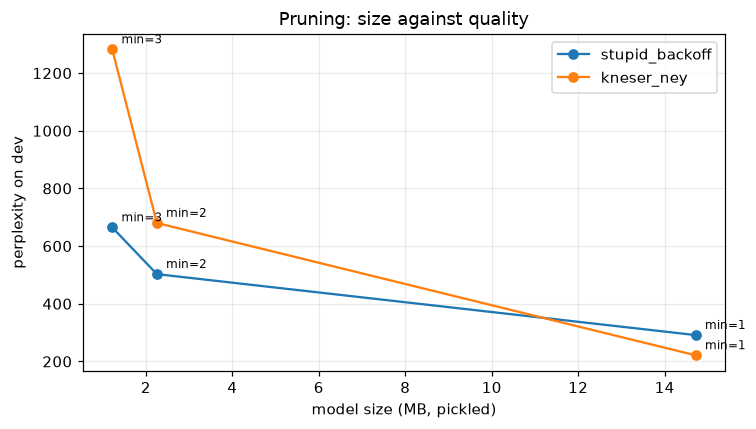

In [13]:
fig, ax = plt.subplots()
for method, rows_p in reports.items():
    ax.plot([r['size_mb'] for r in rows_p], [r['perplexity'] for r in rows_p],
            marker='o', label=method)
    for r in rows_p:
        ax.annotate(f"min={r['min_count']}", (r['size_mb'], r['perplexity']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('model size (MB, pickled)')
ax.set_ylabel('perplexity on dev')
ax.set_title('Pruning: size against quality')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

This is the result that decides what ships, and it is not the one the
perplexity table predicted.

Unpruned, Kneser-Ney wins comfortably (221 against 291). Pruned to a shippable
size, it **loses** — KN degrades roughly three times faster than stupid backoff.
The reason is structural: KN's estimates are built on continuation counts, and
pruning deletes exactly the rare, single-occurrence n-grams those counts are
computed from. Stupid backoff only ever needed raw counts and a fallback path,
so it degrades gracefully.

So the shipped model is stupid backoff — not because it is the better language
model, but because it is the better *pruned* language model, and pruning is not
optional at 15 MB.

## 9. Latency

The constraint that started all of this: a suggestion arriving after the next
keystroke is useless. Budget is `prediction.latency.p95_budget_ms`.

In [14]:
shipped = NgramModel(order=3, smoothing='stupid_backoff').fit(corpus.train)
shipped.prune()

times = []
for _ in range(2000):
    t0 = time.perf_counter()
    shipped.candidates(['in', 'the'], k=3)
    times.append((time.perf_counter() - t0) * 1000)
times.sort()
print(f'p50 {times[len(times) // 2]:.2f} ms')
print(f'p95 {times[int(len(times) * 0.95)]:.2f} ms')
print(f'p99 {times[int(len(times) * 0.99)]:.2f} ms')

p50 0.20 ms
p95 0.32 ms
p99 0.55 ms


## 10. Save the shipped model

In [15]:
path = shipped.save(data_dir('models') / 'ngram_trigram_pruned.pkl')
print(f'{path.name}: {path.stat().st_size / 1e6:.2f} MB, '
      f'{shipped.stats().total_ngrams:,} n-grams, vocab {len(shipped.vocab):,}')

ngram_trigram_pruned.pkl: 2.26 MB, 151,014 n-grams, vocab 24,637


## Summary

| Result | Value |
| --- | --- |
| Trigram MLE perplexity | infinite (unseen n-grams) |
| Best unpruned perplexity | 221 (Kneser-Ney, n=3) |
| Laplace at n=3 | 9,704 — worse than at n=1 |
| Shipped model | trigram, stupid backoff, pruned |
| Size | 14.7 MB -> 2.3 MB (6.5x smaller) |
| n-grams | 1,050,690 -> 151,014 |
| Candidate latency | p50 ~0.2 ms, p95 ~0.4 ms |

The finding worth putting in the report is that the two rankings disagree.
Unpruned, Kneser-Ney is the better model. Pruned to something that fits in a
tray app, stupid backoff is — because KN's quality comes from continuation
counts over rare n-grams, and pruning deletes precisely those.

Next: **Phase 3 — prediction engine**, which puts a prefix trie in front of
this model for word completion and adds a per-user personalisation layer.